In [1]:
import os
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis
import joblib
import pandas as pd

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

# Make sure the output directories exist
os.makedirs(ENSEMBLE_DIR_PATH, exist_ok=True)
os.makedirs(MODELS_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

## Load Historical Emissions Data and Wold Bank Indicators Data

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [7]:
# Load the wb indicators
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators.csv"))
wb_df.head()

,year,pop_total,pop_growth,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,iso_alpha_3
0,2022,731821393.0,2.592754,NaN,NaN,29.737205,2.908437e+12,3.555769,3974.244214,0.905330,30.011775,26.932515,10.538783,27.461822,NaN
1,2021,713090928.0,2.649439,4.939318,NaN,29.955194,2.805001e+12,4.563568,3933.580905,1.829597,26.344785,26.085775,10.411407,25.885464,NaN
2,2020,694446100.0,2.699516,4.585792,65.78238,30.174252,2.681304e+12,-2.859784,3861.068816,-5.447021,24.256267,25.435730,10.447498,22.041722,NaN
3,2019,675950189.0,2.721681,5.173796,62.69071,30.391626,2.753587e+12,2.200340,4073.653989,-0.543715,26.740975,26.422837,10.784120,23.926080,NaN
4,2018,657801085.0,2.734263,3.945917,61.58753,30.611512,2.689356e+12,2.665038,4088.402831,-0.104064,28.520850,27.858301,10.839451,25.306400,NaN


In [8]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              6118 non-null   int64  
 1   pop_total                         6095 non-null   float64
 2   pop_growth                        6094 non-null   float64
 3   electricity_from_renewables_pct   5617 non-null   float64
 4   renewable_energy_consumption_pct  5710 non-null   float64
 5   forest_area_pct                   5953 non-null   float64
 6   gdp_2021_ppp_intl_usd             5628 non-null   float64
 7   gdp_growth_pct                    5860 non-null   float64
 8   gdp_per_capita_2021_ppp_intl_usd  5628 non-null   float64
 9   gdp_per_capita_growth_pct         5860 non-null   float64
 10  imports_pct_of_gdp                5184 non-null   float64
 11  industry_pct_of_gdp               5578 non-null   float64
 12  manufa

## Merge emissions data with World Bank indicators

In [9]:
indicators_and_emissions_df = pd.merge(emissions_df, wb_df, on=["iso_alpha_3", "year"], how="left")
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions,pop_total,pop_growth,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp
0,ABW,High income,Latin America & Caribbean,2000,0.335765,90588.0,1.030817,0.0,0.2,2.333333,3.555111e+09,7.622921,39244.829855,6.519224,70.686869,13.175955,4.100964,74.386011
1,ABW,High income,Latin America & Caribbean,2001,0.344135,91439.0,0.935033,0.0,0.2,2.333333,3.703785e+09,4.182002,40505.533001,3.212406,69.394325,13.054069,4.277073,70.996784
2,ABW,High income,Latin America & Caribbean,2002,0.363222,92074.0,0.692052,0.0,0.2,2.333333,3.668786e+09,-0.944953,39846.062762,-1.628099,68.666458,13.241621,4.425834,64.564314
3,ABW,High income,Latin America & Caribbean,2003,0.412246,93128.0,1.138229,0.0,0.2,2.333333,3.709528e+09,1.110505,39832.579076,-0.033839,70.063078,14.892210,4.777505,62.731213
4,ABW,High income,Latin America & Caribbean,2004,0.430187,95138.0,2.135358,0.0,0.2,2.333333,3.980091e+09,7.293728,41834.927581,5.026912,67.765371,15.596508,5.622020,64.665559


In [10]:
# move total_emissions to the end
indicators_and_emissions_df = indicators_and_emissions_df[[col for col in indicators_and_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,90588.0,1.030817,0.0,0.2,2.333333,3.555111e+09,7.622921,39244.829855,6.519224,70.686869,13.175955,4.100964,74.386011,0.335765
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.935033,0.0,0.2,2.333333,3.703785e+09,4.182002,40505.533001,3.212406,69.394325,13.054069,4.277073,70.996784,0.344135
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.692052,0.0,0.2,2.333333,3.668786e+09,-0.944953,39846.062762,-1.628099,68.666458,13.241621,4.425834,64.564314,0.363222
3,ABW,High income,Latin America & Caribbean,2003,93128.0,1.138229,0.0,0.2,2.333333,3.709528e+09,1.110505,39832.579076,-0.033839,70.063078,14.892210,4.777505,62.731213,0.412246
4,ABW,High income,Latin America & Caribbean,2004,95138.0,2.135358,0.0,0.2,2.333333,3.980091e+09,7.293728,41834.927581,5.026912,67.765371,15.596508,5.622020,64.665559,0.430187


In [11]:
# Load policy index data
policy_index_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, 'IEA_scored_index.csv'))
policy_index_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,policy_index,policy_index_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.912547


In [12]:
# Keep relevant columns
policy_index_df = policy_index_df[['iso_alpha_3', 'year', 'policy_count', 'policy_index']]
policy_index_df.head()

,iso_alpha_3,year,policy_count,policy_index
0,AFG,1971,1,0.51986
1,AFG,1972,1,0.51986
2,AFG,1973,1,0.51986
3,AFG,1974,1,0.51986
4,AFG,1975,1,0.51986


In [13]:
# merge with indicators_and_emissions_df
indicators_and_emissions_df = pd.merge(indicators_and_emissions_df, policy_index_df, on=['iso_alpha_3', 'year'], how='left')
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index
0,ABW,High income,Latin America & Caribbean,2000,90588.0,1.030817,0.0,0.2,2.333333,3.555111e+09,7.622921,39244.829855,6.519224,70.686869,13.175955,4.100964,74.386011,0.335765,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.935033,0.0,0.2,2.333333,3.703785e+09,4.182002,40505.533001,3.212406,69.394325,13.054069,4.277073,70.996784,0.344135,NaN,NaN
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.692052,0.0,0.2,2.333333,3.668786e+09,-0.944953,39846.062762,-1.628099,68.666458,13.241621,4.425834,64.564314,0.363222,NaN,NaN
3,ABW,High income,Latin America & Caribbean,2003,93128.0,1.138229,0.0,0.2,2.333333,3.709528e+09,1.110505,39832.579076,-0.033839,70.063078,14.892210,4.777505,62.731213,0.412246,NaN,NaN
4,ABW,High income,Latin America & Caribbean,2004,95138.0,2.135358,0.0,0.2,2.333333,3.980091e+09,7.293728,41834.927581,5.026912,67.765371,15.596508,5.622020,64.665559,0.430187,NaN,NaN


In [14]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   iso_alpha_3                       4485 non-null   object 
 1   income_group                      4485 non-null   object 
 2   region                            4485 non-null   object 
 3   year                              4485 non-null   int64  
 4   pop_total                         4439 non-null   float64
 5   pop_growth                        4438 non-null   float64
 6   electricity_from_renewables_pct   4194 non-null   float64
 7   renewable_energy_consumption_pct  4301 non-null   float64
 8   forest_area_pct                   4379 non-null   float64
 9   gdp_2021_ppp_intl_usd             4221 non-null   float64
 10  gdp_growth_pct                    4299 non-null   float64
 11  gdp_per_capita_2021_ppp_intl_usd  4221 non-null   float64
 12  gdp_pe

## Data Cleaning

In [15]:
# Fill missing values for numeric columns
indicators_and_emissions_df = dcu.fill_numeric_missing_by_group(indicators_and_emissions_df, ["iso_alpha_3"])

In [16]:
indicators_and_emissions_df.describe()

,year,pop_total,pop_growth,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index
count,4485.000000,4.485000e+03,4485.000000,4485.000000,4485.000000,4485.000000,4.485000e+03,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000,4485.000000
mean,2011.000000,3.632880e+07,1.427284,5.015476,31.719554,32.184038,6.145174e+11,3.488967,23909.461469,2.042366,46.939463,26.401314,11.751161,42.443748,221.511989,18.669119,1.411403
std,6.633989,1.361699e+08,1.562599,10.409616,29.957890,24.120103,2.097214e+12,5.881332,26557.411937,5.784401,26.056860,12.760327,6.438548,29.186247,920.296951,35.702817,0.598969
min,2000.000000,1.764800e+04,-11.356645,-71.056856,0.000000,0.000000,2.113554e+08,-54.336106,702.597885,-55.228864,1.127673,2.390762,0.336370,1.571162,-242.690846,1.000000,0.173287
25%,2005.000000,1.504365e+06,0.442582,0.032096,5.800000,11.073684,2.043273e+10,1.372350,4876.473158,-0.028581,29.299838,18.533510,6.915119,23.245877,3.405074,3.000000,0.961286
50%,2011.000000,7.391448e+06,1.297350,1.271212,21.600000,30.442858,7.420282e+10,3.772544,14104.428172,2.192409,41.190332,24.294213,11.272549,36.886555,36.933154,7.000000,1.336784
75%,2017.000000,2.532945e+07,2.337731,5.805103,53.300000,50.935065,3.868963e+11,5.956274,34804.633186,4.339109,58.918861,31.351556,16.038741,53.792165,116.330198,19.000000,1.854860
max,2022.000000,1.425423e+09,21.700343,97.277228,98.300000,95.577213,3.036089e+13,91.137039,174339.002047,91.781370,221.009959,86.669555,44.980398,228.993771,14511.221700,606.000000,3.106444


In [17]:
# Check which rows have negative electricity_from_renewables_pct
indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] < 0]["iso_alpha_3"].unique()

array(['AGO', 'ARG', 'ARM', 'BEN', 'BFA', 'BGD', 'BOL', 'CIV', 'CMR',
       'COD', 'COG', 'COL', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GEO',
       'GNQ', 'HRV', 'IND', 'IRN', 'IRQ', 'JAM', 'KAZ', 'KEN', 'KGZ',
       'KHM', 'LAO', 'LBN', 'MDG', 'MKD', 'MNG', 'MOZ', 'MYS', 'NAM',
       'NGA', 'NPL', 'PAK', 'PRI', 'PRK', 'PRY', 'SDN', 'SUR', 'TGO',
       'TJK', 'TKM', 'TUN', 'TZA', 'UGA', 'UZB', 'VNM', 'ZAF', 'ZMB'],
      dtype=object)

In [18]:
# Drop electricity_from_renewables_pct column since a lot of countries have negative values
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["electricity_from_renewables_pct"])

In [19]:
# Check negative emissions
negative_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array(['BDI', 'BHS', 'BLZ', 'BTN', 'CAF', 'CMR', 'COG', 'COM', 'DJI',
       'DMA', 'GAB', 'GRD', 'GTM', 'KNA', 'LBR', 'LVA', 'MLI', 'MNG',
       'NAM', 'NER', 'PAN', 'PNG', 'RWA', 'STP', 'SWZ', 'TLS', 'TON',
       'VUT', 'WSM'], dtype=object)

In [20]:
# Drop the rows with negative emissions
indicators_and_emissions_df =indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] >= 0]

In [21]:
# Check for duplicates
duplicates_df = indicators_and_emissions_df[indicators_and_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, income_group, region, year, pop_total, pop_growth, renewable_energy_consumption_pct, forest_area_pct, gdp_2021_ppp_intl_usd, gdp_growth_pct, gdp_per_capita_2021_ppp_intl_usd, gdp_per_capita_growth_pct, imports_pct_of_gdp, industry_pct_of_gdp, manufacturing_pct_of_gdp, exports_pct_of_gdp, total_emissions, policy_count, policy_index]
Index: []


In [22]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = indicators_and_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 14
    iso_alpha_3  count
166         GTM     22
167         TLS     22
168         LVA     20
169         MNG     18
170         RWA     17
171         BDI     17
172         GRD     15
173         COG     14
174         KNA     12
175         DJI     10
176         PNG      9
177         PAN      8
178         DMA      6
179         NER      5


In [23]:
# Remove the countries with less than x records from the indicators_and_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [24]:
# Check the max year for every country
max_year_df = indicators_and_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [25]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   iso_alpha_3                       3818 non-null   object 
 1   income_group                      3818 non-null   object 
 2   region                            3818 non-null   object 
 3   year                              3818 non-null   int64  
 4   pop_total                         3818 non-null   float64
 5   pop_growth                        3818 non-null   float64
 6   renewable_energy_consumption_pct  3818 non-null   float64
 7   forest_area_pct                   3818 non-null   float64
 8   gdp_2021_ppp_intl_usd             3818 non-null   float64
 9   gdp_growth_pct                    3818 non-null   float64
 10  gdp_per_capita_2021_ppp_intl_usd  3818 non-null   float64
 11  gdp_per_capita_growth_pct         3818 non-null   float64
 12  import

In [26]:
indicators_and_emissions_df.describe()

,year,pop_total,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index
count,3818.000000,3.818000e+03,3818.000000,3818.000000,3818.000000,3.818000e+03,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000,3818.000000
mean,2011.000000,4.189125e+07,1.366882,28.615820,30.507370,7.175844e+11,3.470962,26393.843095,2.085013,46.509580,26.996250,12.219881,42.811253,263.966266,21.190938,1.480172
std,6.634118,1.468597e+08,1.585453,28.670433,23.391852,2.257257e+12,5.923633,27807.032116,5.766524,26.141364,12.745243,6.294616,29.256479,991.093662,38.090463,0.602672
min,2000.000000,1.764800e+04,-10.927442,0.000000,0.000000,2.113554e+08,-54.336106,702.597885,-55.228864,1.127673,2.390762,0.336370,1.571162,0.010029,1.000000,0.173287
25%,2005.000000,2.518963e+06,0.400274,5.000000,11.000806,3.017527e+10,1.382725,5595.384698,0.008205,29.083192,19.152716,7.821990,23.903775,10.790480,4.000000,1.039721
50%,2011.000000,9.414590e+06,1.209721,18.200000,28.673066,1.117091e+11,3.748348,15866.401282,2.274036,39.609434,24.797570,11.759447,36.508678,50.996469,8.000000,1.433408
75%,2017.000000,3.042670e+07,2.227048,46.900000,46.460675,5.018922e+11,5.981534,39637.241822,4.409778,59.520536,31.576758,16.352492,53.707563,153.479223,22.000000,1.922224
max,2022.000000,1.425423e+09,21.700343,98.300000,95.577213,3.036089e+13,91.137039,174339.002047,91.781370,221.009959,86.669555,44.980398,228.993771,14511.221700,606.000000,3.106444


In [27]:
indicators_and_emissions_df.iso_alpha_3.unique().shape

(166,)

## Add Lags

In [28]:
# Make sure the df is sorted by iso_alpha_3 and year
indicators_and_emissions_df_sorted = indicators_and_emissions_df.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [29]:
indicators_and_emissions_df_sorted.head()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index
0,ABW,High income,Latin America & Caribbean,2000,90588.0,1.030817,0.2,2.333333,3.555111e+09,7.622921,39244.829855,6.519224,70.686869,13.175955,4.100964,74.386011,0.335765,2.0,0.961286
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.935033,0.2,2.333333,3.703785e+09,4.182002,40505.533001,3.212406,69.394325,13.054069,4.277073,70.996784,0.344135,2.0,0.961286
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.692052,0.2,2.333333,3.668786e+09,-0.944953,39846.062762,-1.628099,68.666458,13.241621,4.425834,64.564314,0.363222,2.0,0.961286
3,ABW,High income,Latin America & Caribbean,2003,93128.0,1.138229,0.2,2.333333,3.709528e+09,1.110505,39832.579076,-0.033839,70.063078,14.892210,4.777505,62.731213,0.412246,2.0,0.961286
4,ABW,High income,Latin America & Caribbean,2004,95138.0,2.135358,0.2,2.333333,3.980091e+09,7.293728,41834.927581,5.026912,67.765371,15.596508,5.622020,64.665559,0.430187,2.0,0.961286


In [30]:
indicators_and_emissions_df_sorted.tail()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,gdp_per_capita_2021_ppp_intl_usd,gdp_per_capita_growth_pct,imports_pct_of_gdp,industry_pct_of_gdp,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index
3813,ZWE,Lower middle income,Africa Eastern and Southern,2018,15034452.0,1.487416,79.7,45.332093,5.371782e+10,5.009921,3572.981340,3.459545,28.386265,31.037911,13.678143,26.164051,47.509033,11.0,1.524829
3814,ZWE,Lower middle income,Africa Eastern and Southern,2019,15271368.0,1.563534,81.0,45.213002,5.031616e+10,-6.332450,3294.803892,-7.785584,28.241814,32.025943,14.222358,27.554170,46.442562,12.0,1.603093
3815,ZWE,Lower middle income,Africa Eastern and Southern,2020,15526888.0,1.659353,84.1,45.093912,4.638298e+10,-7.816933,2987.268413,-9.333954,25.020311,32.767518,15.696567,22.293071,44.576343,12.0,1.603093
3816,ZWE,Lower middle income,Africa Eastern and Southern,2021,15797210.0,1.726011,82.4,44.974822,5.031071e+10,8.468039,3184.784602,6.611933,28.071885,28.805586,12.442934,22.775238,45.759664,13.0,1.573284
3817,ZWE,Lower middle income,Africa Eastern and Southern,2022,16069056.0,1.706209,81.2,44.855732,5.339937e+10,6.139176,3323.118318,4.343582,36.891437,39.691641,20.533465,27.872170,46.423948,13.0,1.573284


In [31]:
# NOTE: why we only generated lags for gdp and pop_total?
training_df_lags = fe.generate_lagged_features(indicators_and_emissions_df_sorted, ["gdp_2021_ppp_intl_usd", 
                                                          "pop_total", "policy_count", "policy_index", "total_emissions"], max_lag=1)

In [32]:
training_df_lags.head()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,...,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index,gdp_2021_ppp_intl_usd_lag1,pop_total_lag1,policy_count_lag1,policy_index_lag1,total_emissions_lag1
0,ABW,High income,Latin America & Caribbean,2000,90588.0,1.030817,0.2,2.333333,3.555111e+09,7.622921,...,4.100964,74.386011,0.335765,2.0,0.961286,NaN,NaN,NaN,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.935033,0.2,2.333333,3.703785e+09,4.182002,...,4.277073,70.996784,0.344135,2.0,0.961286,3.555111e+09,90588.0,2.0,0.961286,0.335765
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.692052,0.2,2.333333,3.668786e+09,-0.944953,...,4.425834,64.564314,0.363222,2.0,0.961286,3.703785e+09,91439.0,2.0,0.961286,0.344135
3,ABW,High income,Latin America & Caribbean,2003,93128.0,1.138229,0.2,2.333333,3.709528e+09,1.110505,...,4.777505,62.731213,0.412246,2.0,0.961286,3.668786e+09,92074.0,2.0,0.961286,0.363222
4,ABW,High income,Latin America & Caribbean,2004,95138.0,2.135358,0.2,2.333333,3.980091e+09,7.293728,...,5.622020,64.665559,0.430187,2.0,0.961286,3.709528e+09,93128.0,2.0,0.961286,0.412246


In [33]:
training_df_lags.dropna(inplace=True)

In [34]:
training_df_lags.head()

,iso_alpha_3,income_group,region,year,pop_total,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_2021_ppp_intl_usd,gdp_growth_pct,...,manufacturing_pct_of_gdp,exports_pct_of_gdp,total_emissions,policy_count,policy_index,gdp_2021_ppp_intl_usd_lag1,pop_total_lag1,policy_count_lag1,policy_index_lag1,total_emissions_lag1
1,ABW,High income,Latin America & Caribbean,2001,91439.0,0.935033,0.2,2.333333,3.703785e+09,4.182002,...,4.277073,70.996784,0.344135,2.0,0.961286,3.555111e+09,90588.0,2.0,0.961286,0.335765
2,ABW,High income,Latin America & Caribbean,2002,92074.0,0.692052,0.2,2.333333,3.668786e+09,-0.944953,...,4.425834,64.564314,0.363222,2.0,0.961286,3.703785e+09,91439.0,2.0,0.961286,0.344135
3,ABW,High income,Latin America & Caribbean,2003,93128.0,1.138229,0.2,2.333333,3.709528e+09,1.110505,...,4.777505,62.731213,0.412246,2.0,0.961286,3.668786e+09,92074.0,2.0,0.961286,0.363222
4,ABW,High income,Latin America & Caribbean,2004,95138.0,2.135358,0.2,2.333333,3.980091e+09,7.293728,...,5.622020,64.665559,0.430187,2.0,0.961286,3.709528e+09,93128.0,2.0,0.961286,0.412246
5,ABW,High income,Latin America & Caribbean,2005,97635.0,2.590757,0.2,2.333333,3.964842e+09,-0.383138,...,6.187295,68.075298,0.462648,2.0,0.961286,3.980091e+09,95138.0,2.0,0.961286,0.430187


In [35]:
training_df_lags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3652 entries, 1 to 3817
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   iso_alpha_3                       3652 non-null   object 
 1   income_group                      3652 non-null   object 
 2   region                            3652 non-null   object 
 3   year                              3652 non-null   int64  
 4   pop_total                         3652 non-null   float64
 5   pop_growth                        3652 non-null   float64
 6   renewable_energy_consumption_pct  3652 non-null   float64
 7   forest_area_pct                   3652 non-null   float64
 8   gdp_2021_ppp_intl_usd             3652 non-null   float64
 9   gdp_growth_pct                    3652 non-null   float64
 10  gdp_per_capita_2021_ppp_intl_usd  3652 non-null   float64
 11  gdp_per_capita_growth_pct         3652 non-null   float64
 12  imports_pct

## EDA 1

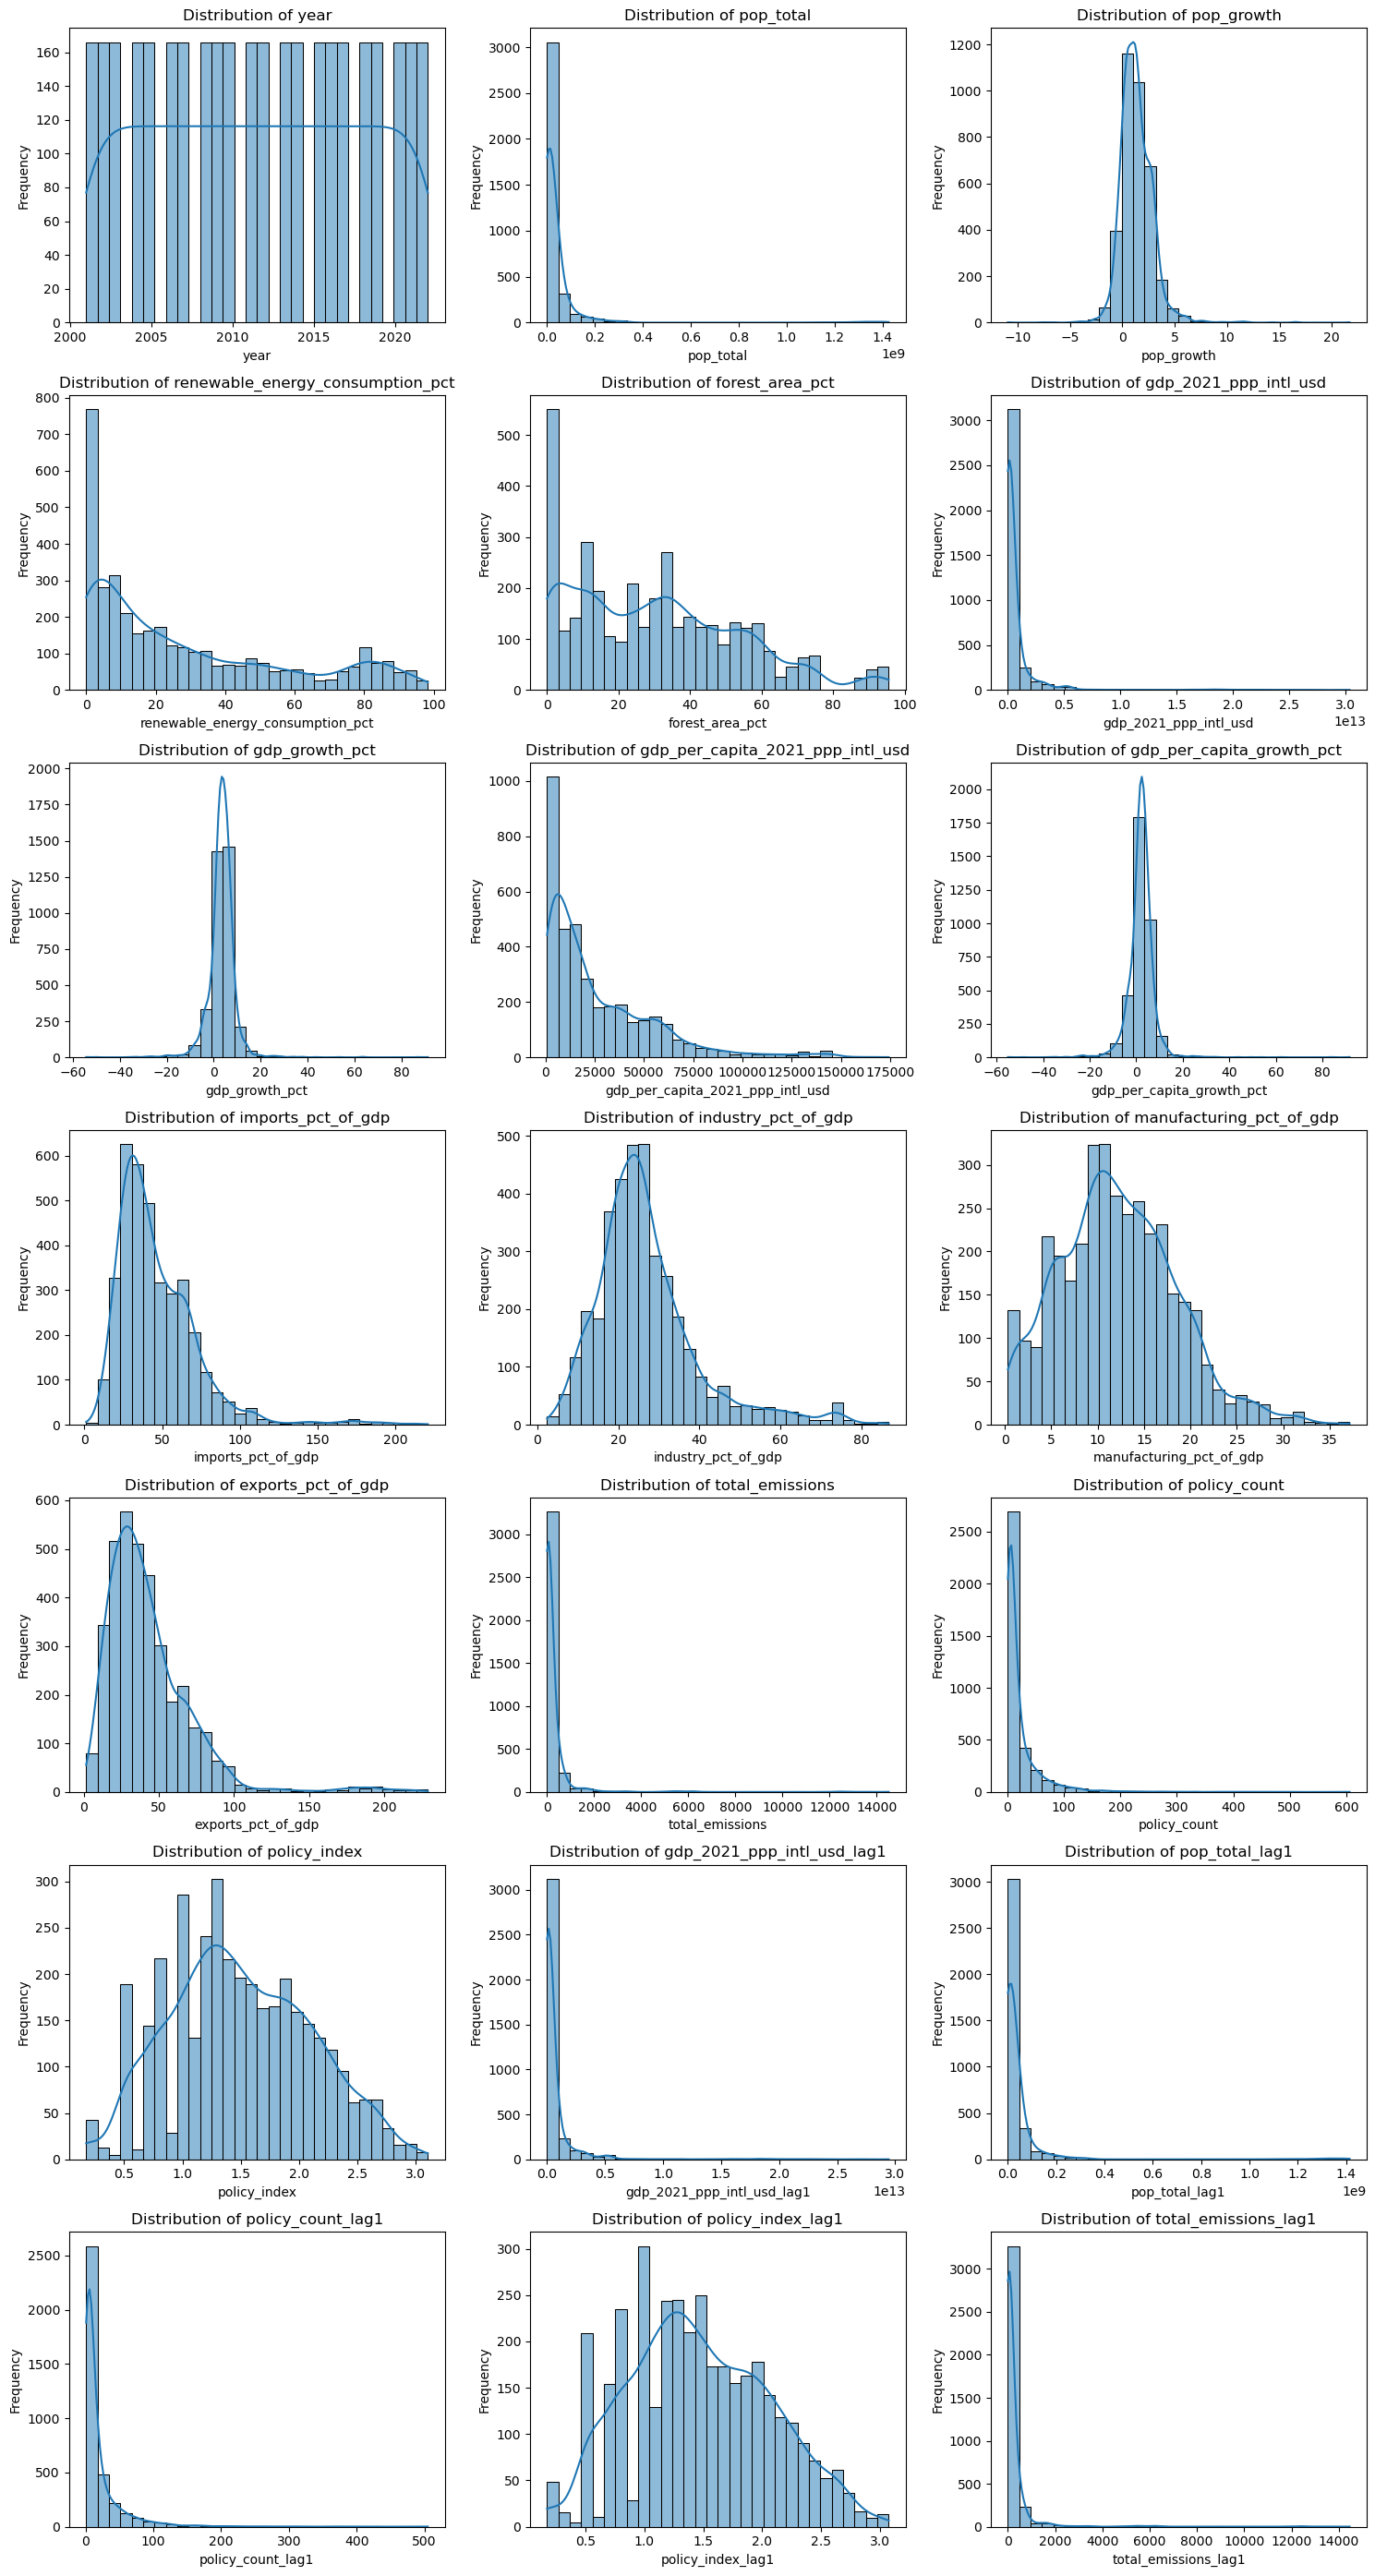

In [36]:
eda_utils.plot_numeric_fields_distributions(training_df_lags)

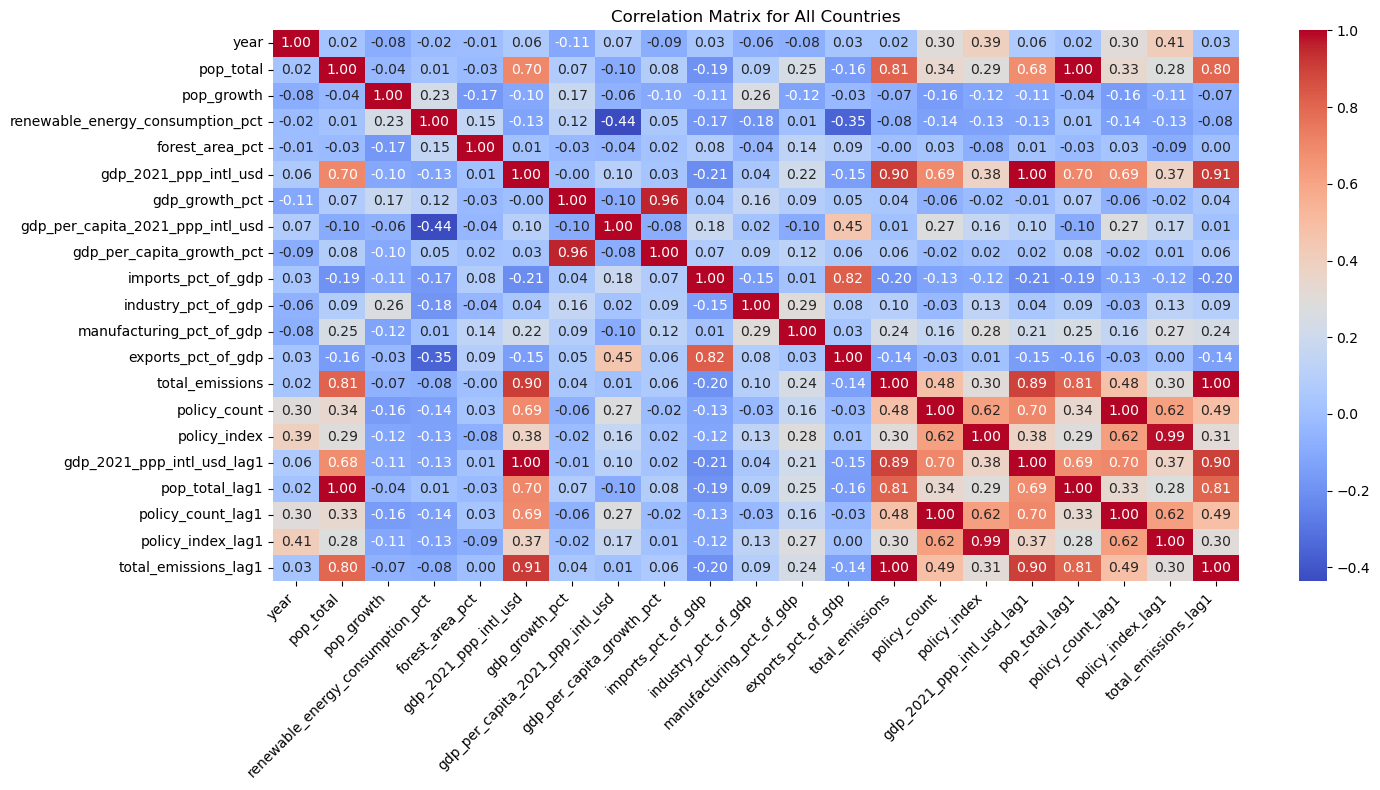

In [37]:
eda_utils.plot_correlation_matrix(training_df_lags, figsize=(15,8))

## Feature Engineering for Numeric Features

In [38]:
# Get the numeric columns
numeric_cols = training_df_lags.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['pop_total',
 'pop_growth',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_2021_ppp_intl_usd',
 'gdp_growth_pct',
 'gdp_per_capita_2021_ppp_intl_usd',
 'gdp_per_capita_growth_pct',
 'imports_pct_of_gdp',
 'industry_pct_of_gdp',
 'manufacturing_pct_of_gdp',
 'exports_pct_of_gdp',
 'total_emissions',
 'policy_count',
 'policy_index',
 'gdp_2021_ppp_intl_usd_lag1',
 'pop_total_lag1',
 'policy_count_lag1',
 'policy_index_lag1',
 'total_emissions_lag1']

In [39]:
# Log transform the numeric columns with high skewness
training_df_log_transformed = fe.log_transform_high_skew(training_df_lags, numeric_cols, skew_threshold=1.0)
training_df_log_transformed.head()

Columns dropped due to high skewness: ['pop_total', 'gdp_2021_ppp_intl_usd', 'gdp_per_capita_2021_ppp_intl_usd', 'imports_pct_of_gdp', 'industry_pct_of_gdp', 'exports_pct_of_gdp', 'total_emissions', 'policy_count', 'gdp_2021_ppp_intl_usd_lag1', 'pop_total_lag1', 'policy_count_lag1', 'total_emissions_lag1']


,iso_alpha_3,income_group,region,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,...,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_total_emissions,log_policy_count,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,log_policy_count_lag1,log_total_emissions_lag1
1,ABW,High income,Latin America & Caribbean,2001,0.935033,0.2,2.333333,4.182002,3.212406,4.277073,...,10.609219,4.254113,2.642912,4.276621,0.295751,1.098612,21.991652,11.414088,1.098612,0.289504
2,ABW,High income,Latin America & Caribbean,2002,0.692052,0.2,2.333333,-0.944953,-1.628099,4.425834,...,10.592804,4.243719,2.656169,4.183032,0.309851,1.098612,22.032621,11.423438,1.098612,0.295751
3,ABW,High income,Latin America & Caribbean,2003,1.138229,0.2,2.333333,1.110505,-0.033839,4.777505,...,10.592466,4.263568,2.765829,4.154674,0.345181,1.098612,22.023127,11.430359,1.098612,0.309851
4,ABW,High income,Latin America & Caribbean,2004,2.135358,0.2,2.333333,7.293728,5.026912,5.622020,...,10.641511,4.230700,2.809192,4.184575,0.357805,1.098612,22.034171,11.441741,1.098612,0.345181
5,ABW,High income,Latin America & Caribbean,2005,2.590757,0.2,2.333333,-0.383138,-2.930823,6.187295,...,10.611765,4.356388,2.850560,4.235197,0.380248,1.098612,22.104571,11.463094,1.098612,0.357805


In [40]:
training_df_log_transformed.describe()

,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,policy_index,policy_index_lag1,log_pop_total,...,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_total_emissions,log_policy_count,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,log_policy_count_lag1,log_total_emissions_lag1
count,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,...,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,2011.500000,1.362530,28.532037,30.487990,3.442415,2.061620,12.163345,1.499370,1.464745,15.754034,...,9.584148,3.738787,3.236666,3.599986,3.791916,2.399722,25.405228,15.740564,2.331031,3.779465
std,6.345158,1.598267,28.564022,23.372109,5.976953,5.811262,6.253694,0.601764,0.598182,2.171881,...,1.205698,0.494414,0.437539,0.607244,1.930787,1.137826,2.121437,2.171951,1.119143,1.932668
min,2001.000000,-10.927442,0.000000,0.000000,-54.336106,-55.228864,0.336370,0.173287,0.173287,9.778434,...,6.584957,0.755029,1.221055,0.944358,0.009979,0.693147,19.169051,9.778434,0.693147,0.009979
25%,2006.000000,0.393107,5.075000,10.995311,1.344536,-0.010067,7.778256,1.039721,1.039721,14.757104,...,8.637435,3.405203,3.001460,3.218820,2.477529,1.609438,24.117281,14.734655,1.386294,2.458199
50%,2011.500000,1.194972,18.200000,28.694570,3.692409,2.230228,11.681471,1.442955,1.414684,16.061279,...,9.688728,3.707475,3.249822,3.625116,3.952569,2.197225,25.421095,16.052605,2.197225,3.948918
75%,2017.000000,2.227739,46.700000,46.405971,5.983063,4.403731,16.288118,1.934322,1.899923,17.238215,...,10.592112,4.106599,3.483599,4.003142,5.051764,3.178054,26.929423,17.218693,3.044522,5.034375
max,2022.000000,21.700343,98.300000,95.551663,91.137039,91.781370,37.146829,3.106444,3.073842,21.077735,...,12.068763,5.402722,4.473575,5.438052,9.582746,6.408529,31.013316,21.069833,6.226537,9.579173


In [41]:
training_df_log_transformed.isna().sum()

iso_alpha_3                             0
income_group                            0
region                                  0
year                                    0
pop_growth                              0
renewable_energy_consumption_pct        0
forest_area_pct                         0
gdp_growth_pct                          0
gdp_per_capita_growth_pct               0
manufacturing_pct_of_gdp                0
policy_index                            0
policy_index_lag1                       0
log_pop_total                           0
log_gdp_2021_ppp_intl_usd               0
log_gdp_per_capita_2021_ppp_intl_usd    0
log_imports_pct_of_gdp                  0
log_industry_pct_of_gdp                 0
log_exports_pct_of_gdp                  0
log_total_emissions                     0
log_policy_count                        0
log_gdp_2021_ppp_intl_usd_lag1          0
log_pop_total_lag1                      0
log_policy_count_lag1                   0
log_total_emissions_lag1          

In [42]:
training_df_lags.isna().sum()

iso_alpha_3                         0
income_group                        0
region                              0
year                                0
pop_total                           0
pop_growth                          0
renewable_energy_consumption_pct    0
forest_area_pct                     0
gdp_2021_ppp_intl_usd               0
gdp_growth_pct                      0
gdp_per_capita_2021_ppp_intl_usd    0
gdp_per_capita_growth_pct           0
imports_pct_of_gdp                  0
industry_pct_of_gdp                 0
manufacturing_pct_of_gdp            0
exports_pct_of_gdp                  0
total_emissions                     0
policy_count                        0
policy_index                        0
gdp_2021_ppp_intl_usd_lag1          0
pop_total_lag1                      0
policy_count_lag1                   0
policy_index_lag1                   0
total_emissions_lag1                0
dtype: int64

## EDA log transformed data

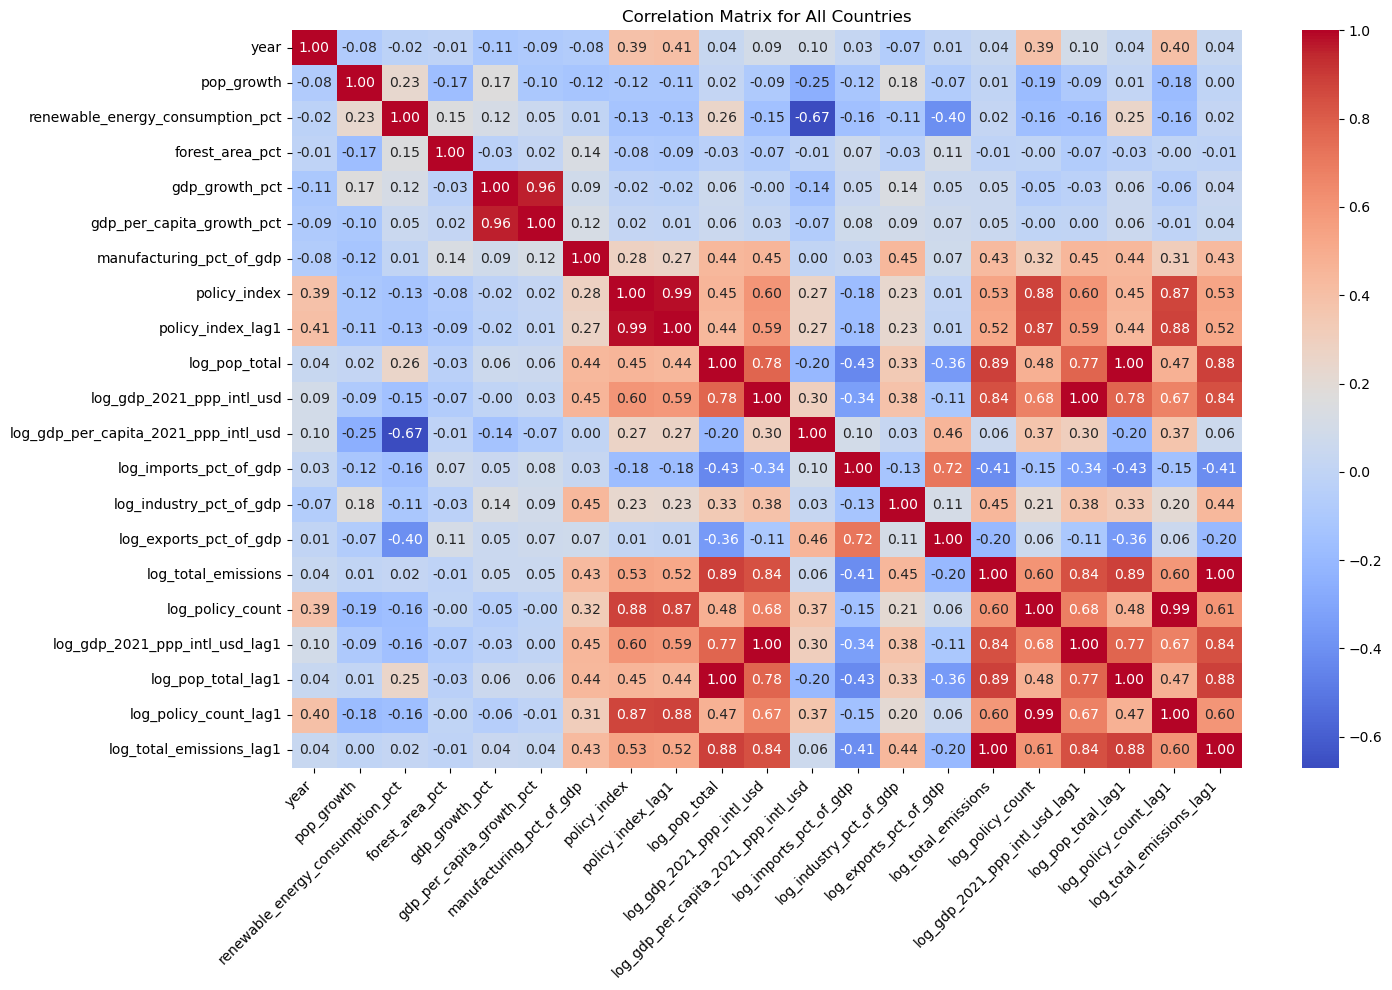

In [43]:
eda_utils.plot_correlation_matrix(training_df_log_transformed, figsize=(15,10))

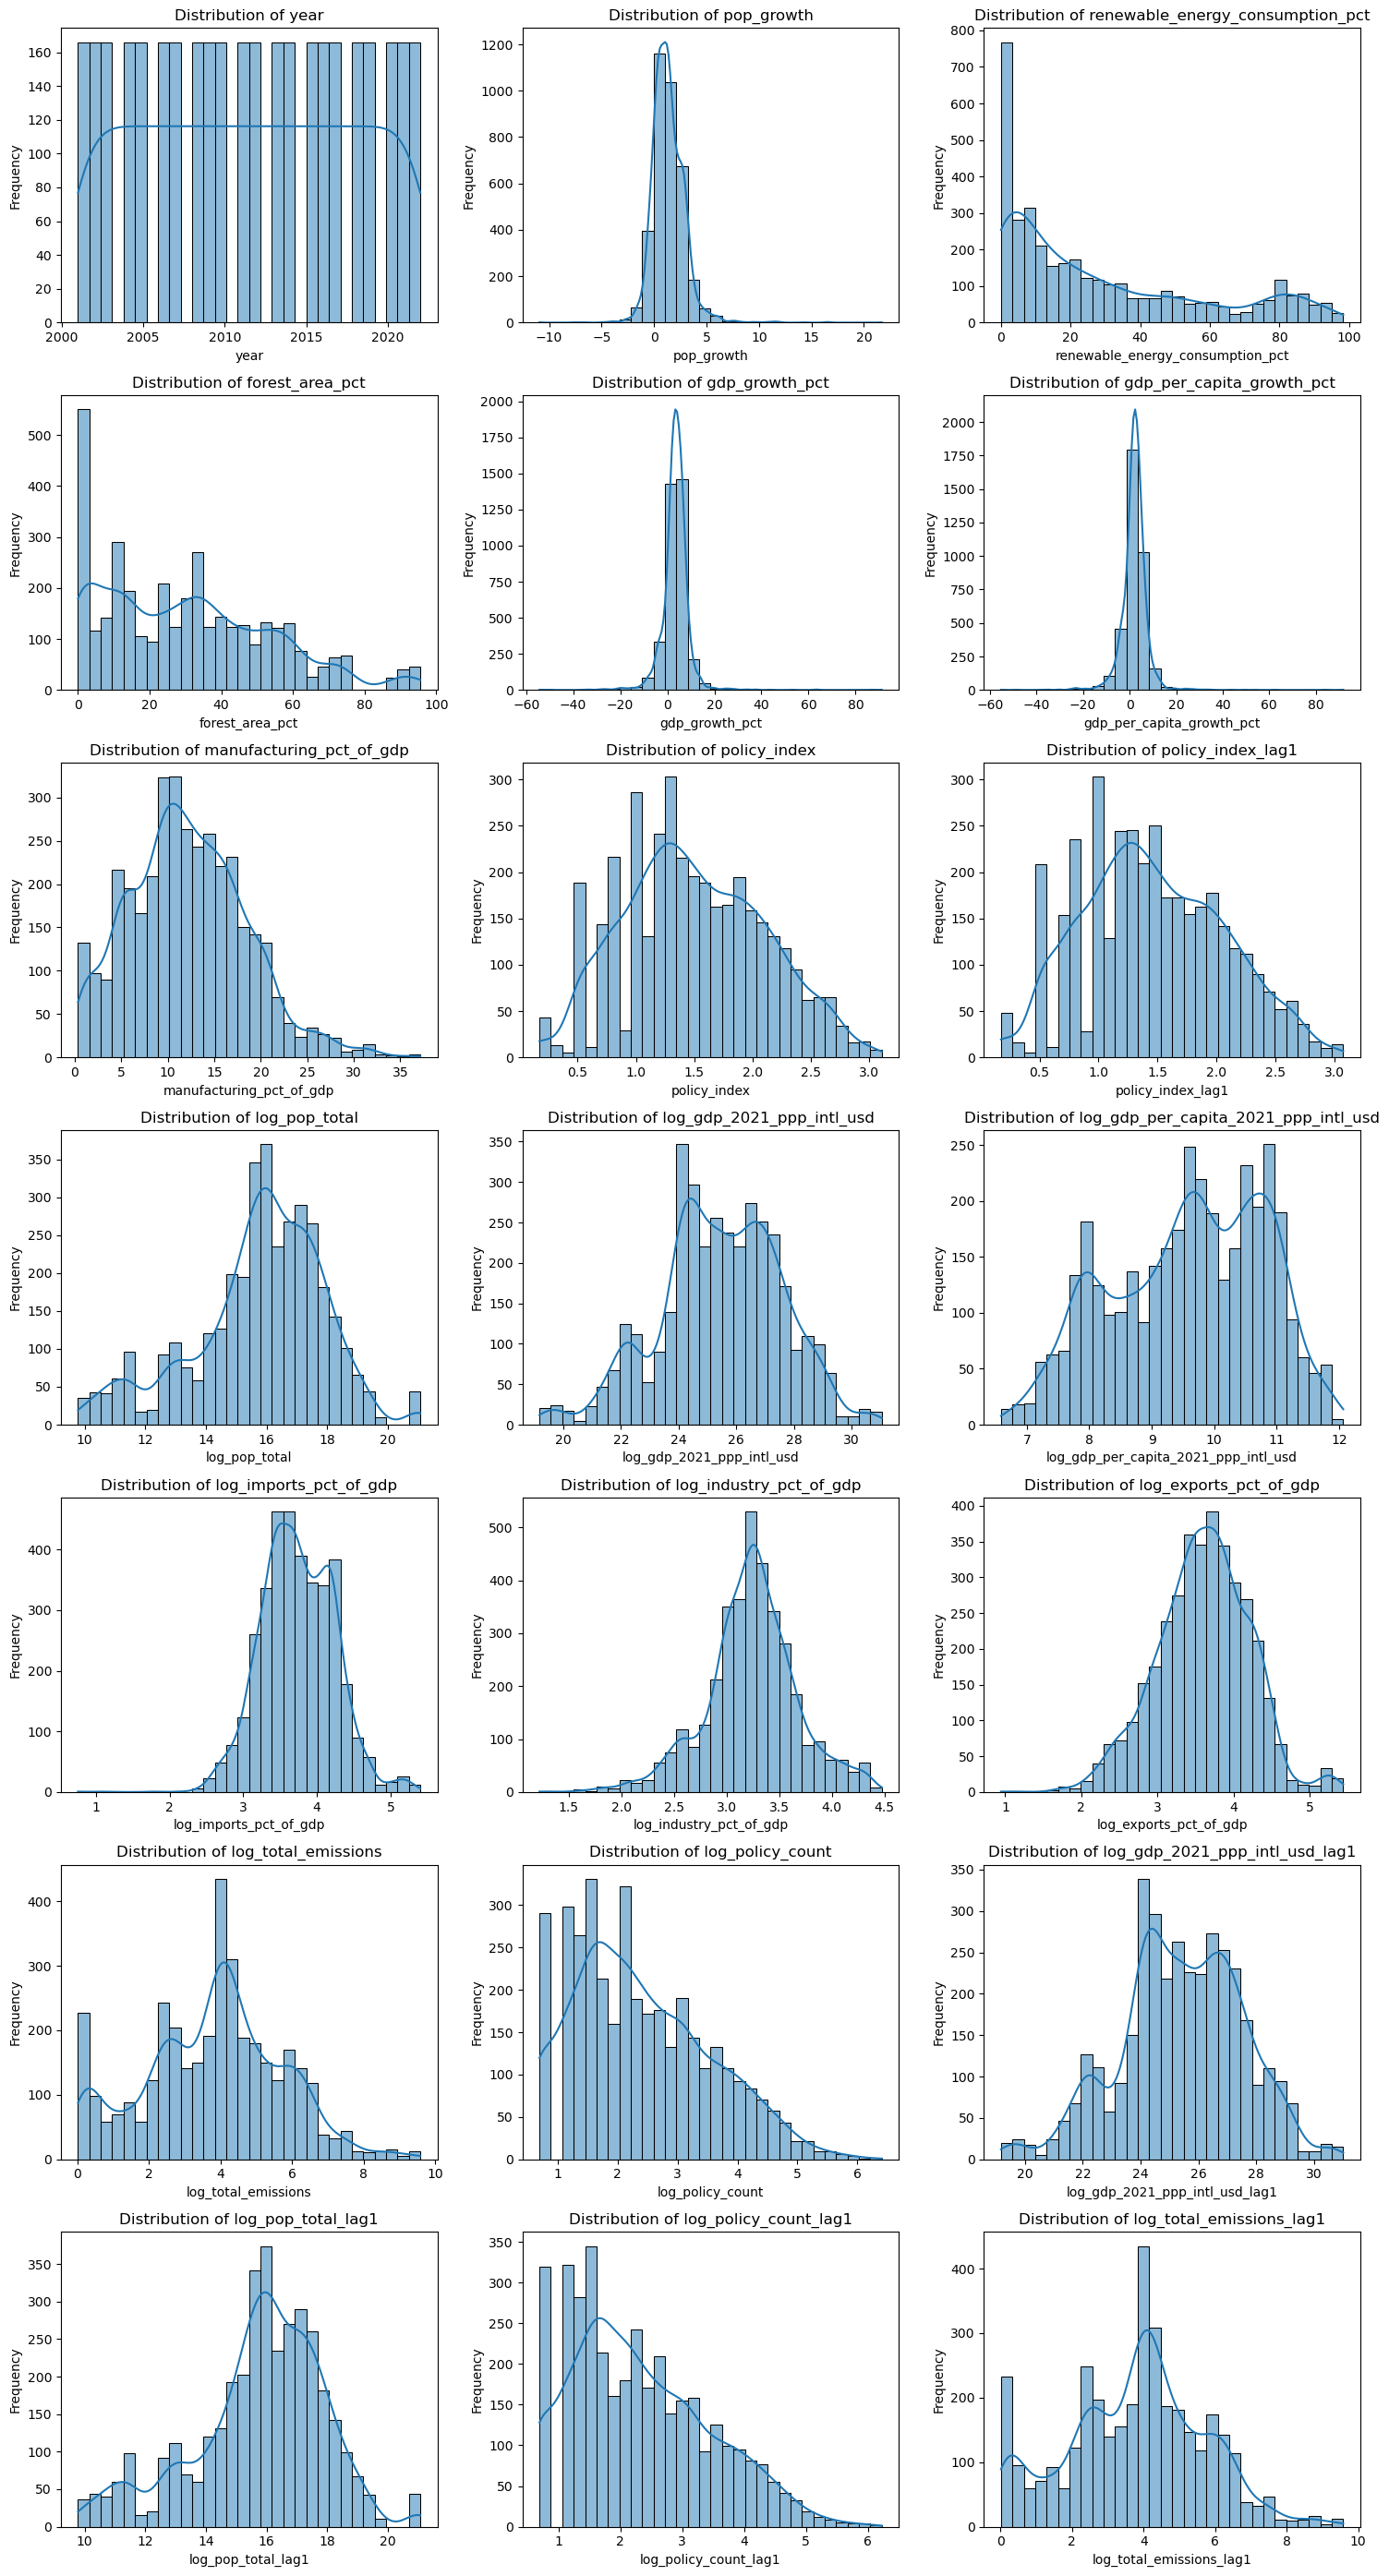

In [44]:
eda_utils.plot_numeric_fields_distributions(training_df_log_transformed)

In [45]:
eda_utils.find_outlier_columns(training_df_log_transformed)

{'pop_growth': 1.1500547645125958,
 'gdp_growth_pct': 1.642935377875137,
 'gdp_per_capita_growth_pct': 1.4238773274917853,
 'manufacturing_pct_of_gdp': 0.6845564074479736,
 'log_imports_pct_of_gdp': 0.547645125958379,
 'log_industry_pct_of_gdp': 0.6297918948521358,
 'log_exports_pct_of_gdp': 0.30120481927710846,
 'log_policy_count': 0.19167579408543264,
 'log_policy_count_lag1': 0.24644030668127057,
 'log_total_emissions_lag1': 0.027382256297918947}

## ML

In [46]:
training_df_log_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3652 entries, 1 to 3817
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   iso_alpha_3                           3652 non-null   object 
 1   income_group                          3652 non-null   object 
 2   region                                3652 non-null   object 
 3   year                                  3652 non-null   int64  
 4   pop_growth                            3652 non-null   float64
 5   renewable_energy_consumption_pct      3652 non-null   float64
 6   forest_area_pct                       3652 non-null   float64
 7   gdp_growth_pct                        3652 non-null   float64
 8   gdp_per_capita_growth_pct             3652 non-null   float64
 9   manufacturing_pct_of_gdp              3652 non-null   float64
 10  policy_index                          3652 non-null   float64
 11  policy_index_lag1     

In [47]:
# Make sure the df is sorted by iso_alpha_3 and year
training_df_log_transformed = training_df_log_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [48]:
training_df_log_transformed_no_emissions_lag = training_df_log_transformed.drop(columns=["log_total_emissions_lag1"]).copy()

Running regression without group feature...

Cross-Validation Results (GroupKFold + TimeSeriesSplit):
------------------------------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
------------------------------------------------------------------------------------------------------------------------
RandomForest          0.0883   0.0230       0.1181    0.0625       0.9933    0.0027       0.9868    0.0147
XGBoost               0.1406   0.0219       0.2124    0.0586       0.9888    0.0025       0.9711    0.0193
ElasticNet            0.0533   0.0026       0.0626    0.0119       0.9971    0.0011       0.9968    0.0016
Median                1.5212   0.1679       1.5295    0.1598      -0.0182    0.0201      -0.0417    0.0821

Evaluation Results:
--------------------------------------------------------------------------------
Model            Train

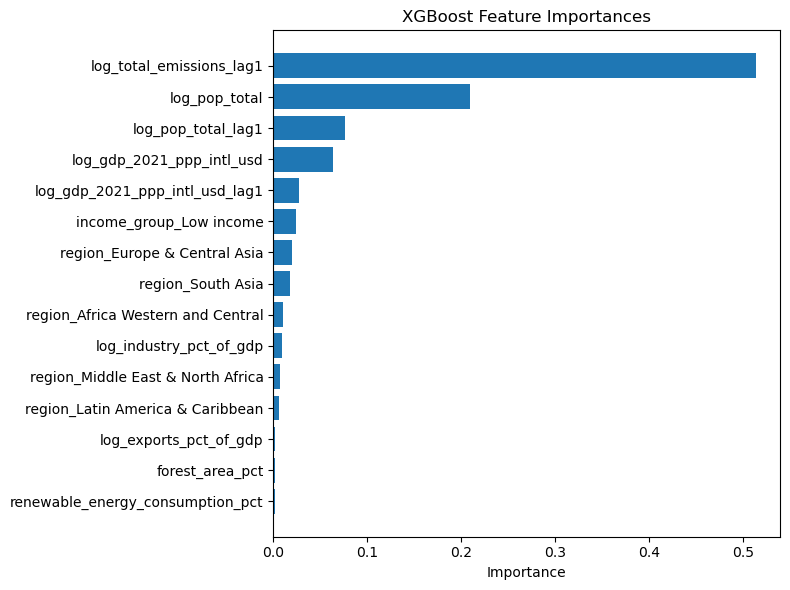

Running regression without group feature...

Cross-Validation Results (GroupKFold + TimeSeriesSplit):
------------------------------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
------------------------------------------------------------------------------------------------------------------------
RandomForest          0.5596   0.0795       0.6983    0.0773       0.8441    0.0529       0.7474    0.0627
XGBoost               0.5573   0.0794       0.6828    0.0827       0.8483    0.0596       0.7562    0.0573
ElasticNet            0.5695   0.0570       0.5941    0.0924       0.8429    0.0549       0.8190    0.0877
Median                1.5212   0.1679       1.5295    0.1598      -0.0182    0.0201      -0.0417    0.0821

Evaluation Results:
--------------------------------------------------------------------------------
Model            Train

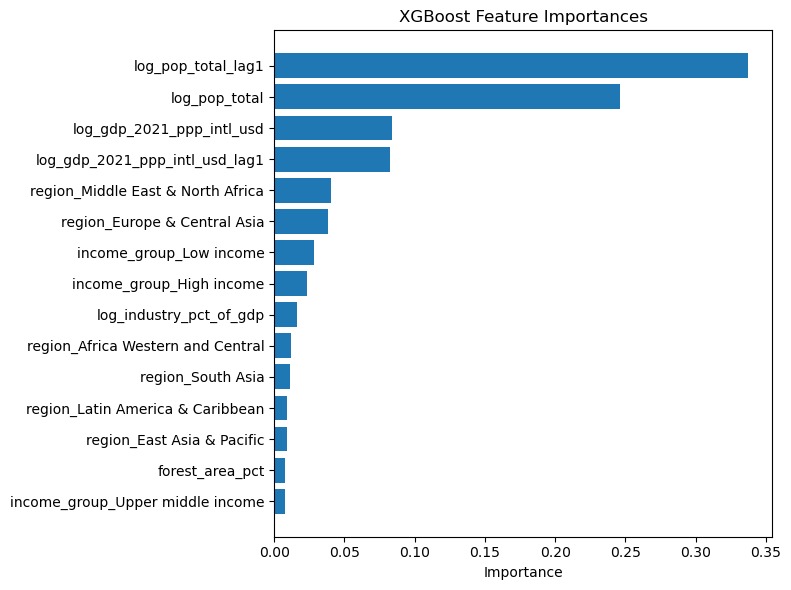

In [49]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

reg_no_isos = RegressionAnalysis(training_df_log_transformed,
                            target_col="log_total_emissions",
                            group_col="iso_alpha_3",
                            year_col="year",
                            scaler_type="minmax",
                            use_group_feature=False,
                            xgb_params=xgb_params
                            )

reg_no_isos.run_all(plot_importances=True, importances_model='xgboost')

# print("Running regression with group feature...")

# reg_with_isos = RegressionAnalysis(training_df_log_transformed,
#                            target_col="log_total_emissions",
#                            group_col="iso_alpha_3",
#                            year_col="year",
#                            scaler_type="minmax",
#                            use_group_feature=True,
#                            xgb_params=xgb_params
#                            )

# reg_with_isos.run_all(plot_importances=True, importances_model='xgboost')

print("Running regression without group feature...")

reg_no_isos_no_em_lags = RegressionAnalysis(training_df_log_transformed_no_emissions_lag,
                            target_col="log_total_emissions",
                            group_col="iso_alpha_3",
                            year_col="year",
                            scaler_type="minmax",
                            use_group_feature=False,
                            xgb_params=xgb_params
                            )

reg_no_isos_no_em_lags.run_all(plot_importances=True, importances_model='xgboost')

# print("Running regression with group feature...")

# reg_with_isos = RegressionAnalysis(training_df_log_transformed_no_emissions_lag,
#                            target_col="log_total_emissions",
#                            group_col="iso_alpha_3",
#                            year_col="year",
#                            scaler_type="minmax",
#                            use_group_feature=True,
#                            xgb_params=xgb_params
#                            )

# reg_with_isos.run_all(plot_importances=True, importances_model='xgboost')

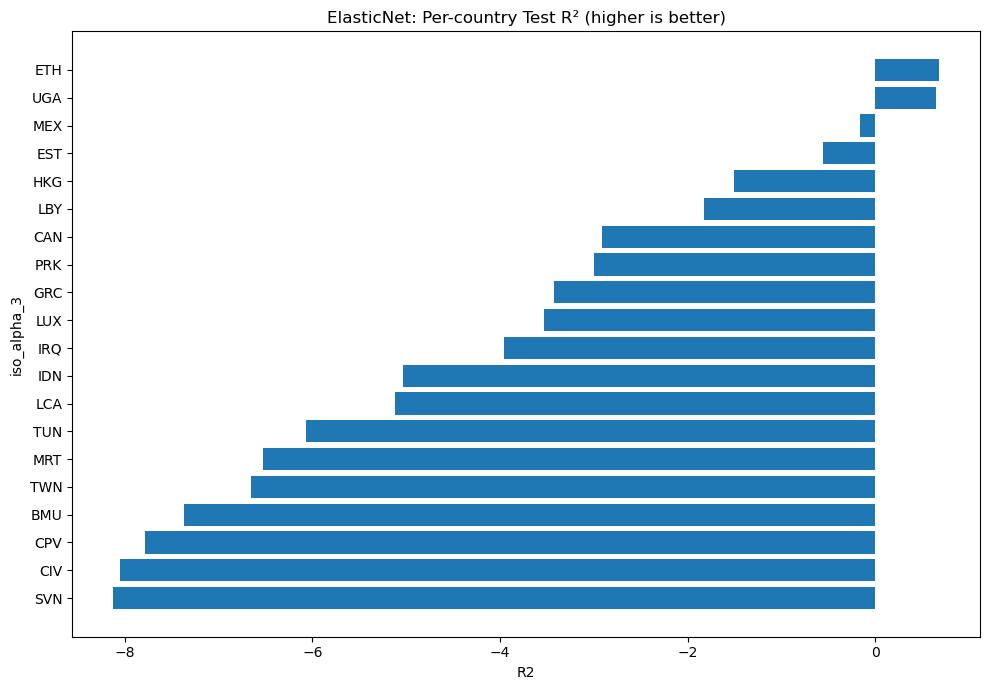

In [50]:
reg_no_isos_no_em_lags.plot_per_country_metric(model='ElasticNet', metric='r2', top_k=20)


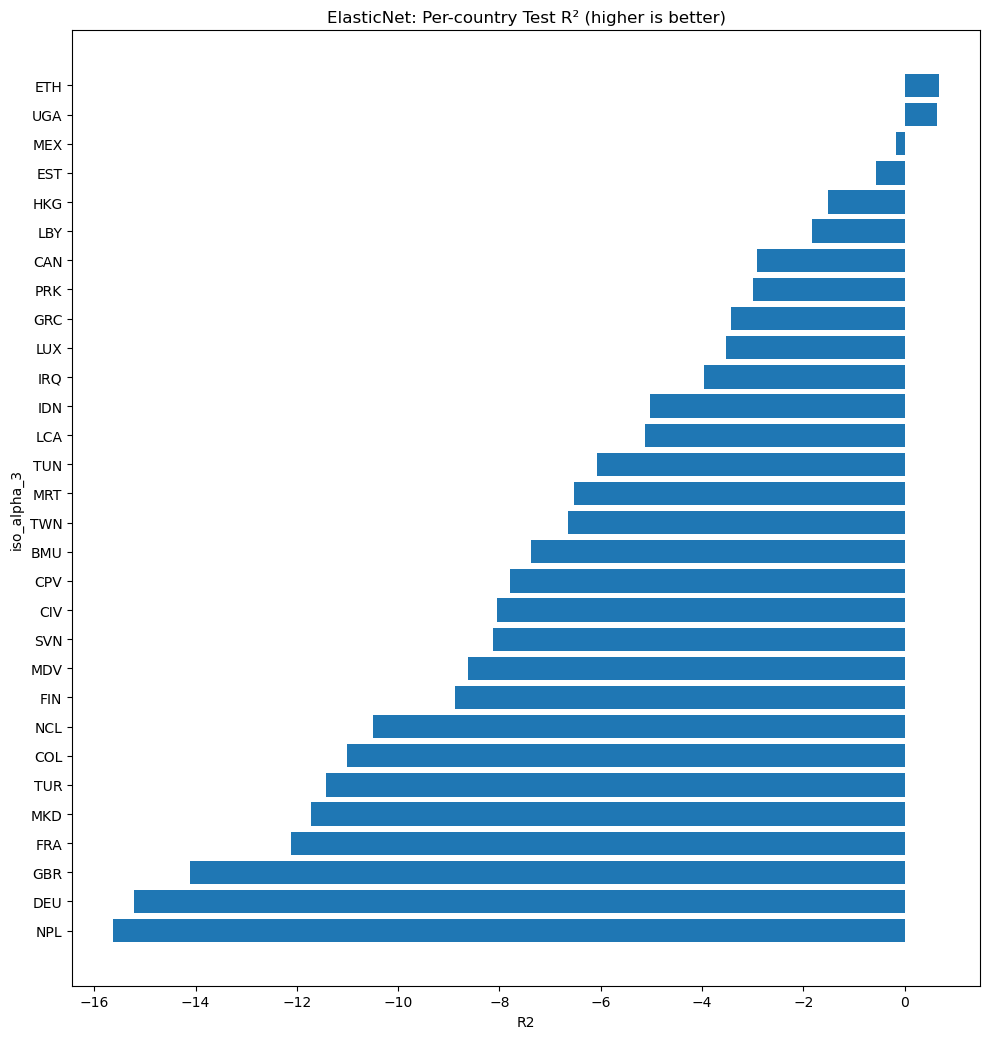

In [51]:
reg_no_isos_no_em_lags.plot_per_country_metric(model='ElasticNet', metric='r2', top_k=30)

In [52]:
# Save the training data to csv files
training_df_log_transformed.to_csv(os.path.join(TRAINING_DIR_PATH, "training_df_log_transformed.csv"), index=False)
training_df_lags.to_csv(os.path.join(TRAINING_DIR_PATH, "training_df_lags.csv"), index=False)

# Save the trained models
trained_pipelines = {
    "reg_no_isos_enet": reg_no_isos.pipe_enet,
    "reg_no_isos_no_em_lags_enet": reg_no_isos_no_em_lags.pipe_enet
}

rewrite_existing_models = True


for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline.pkl"
    MODEL_PATH = os.path.join(MODELS_DIR_PATH, model_file_name)
    if os.path.exists(MODEL_PATH):
        if rewrite_existing_models:
            print(f"Overwriting existing model {model_file_name} at {MODEL_PATH}.")
            joblib.dump(pipeline, MODEL_PATH)
        else:
            print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
    else:
        print(f"Saving model {model_file_name} to {MODEL_PATH}.")
        joblib.dump(pipeline, MODEL_PATH)

Overwriting existing model reg_no_isos_enet_pipeline.pkl at /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/reg_no_isos_enet_pipeline.pkl.
Saving model reg_no_isos_no_em_lags_enet_pipeline.pkl to /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/reg_no_isos_no_em_lags_enet_pipeline.pkl.
